In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df.describe())

Shape of dataset: (3999, 12)

First 5 rows:
   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  

Data Types:


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

Duplicate rows: 0


In [5]:
for col in ['cc1_miles', 'cc2_miles', 'cc3_miles', 'Award?']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts().sort_index())


cc1_miles value counts:
cc1_miles
1    2289
2     284
3     613
4     525
5     288
Name: count, dtype: int64

cc2_miles value counts:
cc2_miles
1    3956
2      28
3      15
Name: count, dtype: int64

cc3_miles value counts:
cc3_miles
1    3981
2       3
3       4
4       6
5       5
Name: count, dtype: int64

Award? value counts:
Award?
0    2518
1    1481
Name: count, dtype: int64


In [6]:
df_clean = df.drop(columns=['ID#'])
print("Shape after dropping ID#:", df_clean.shape)

Shape after dropping ID#: (3999, 11)


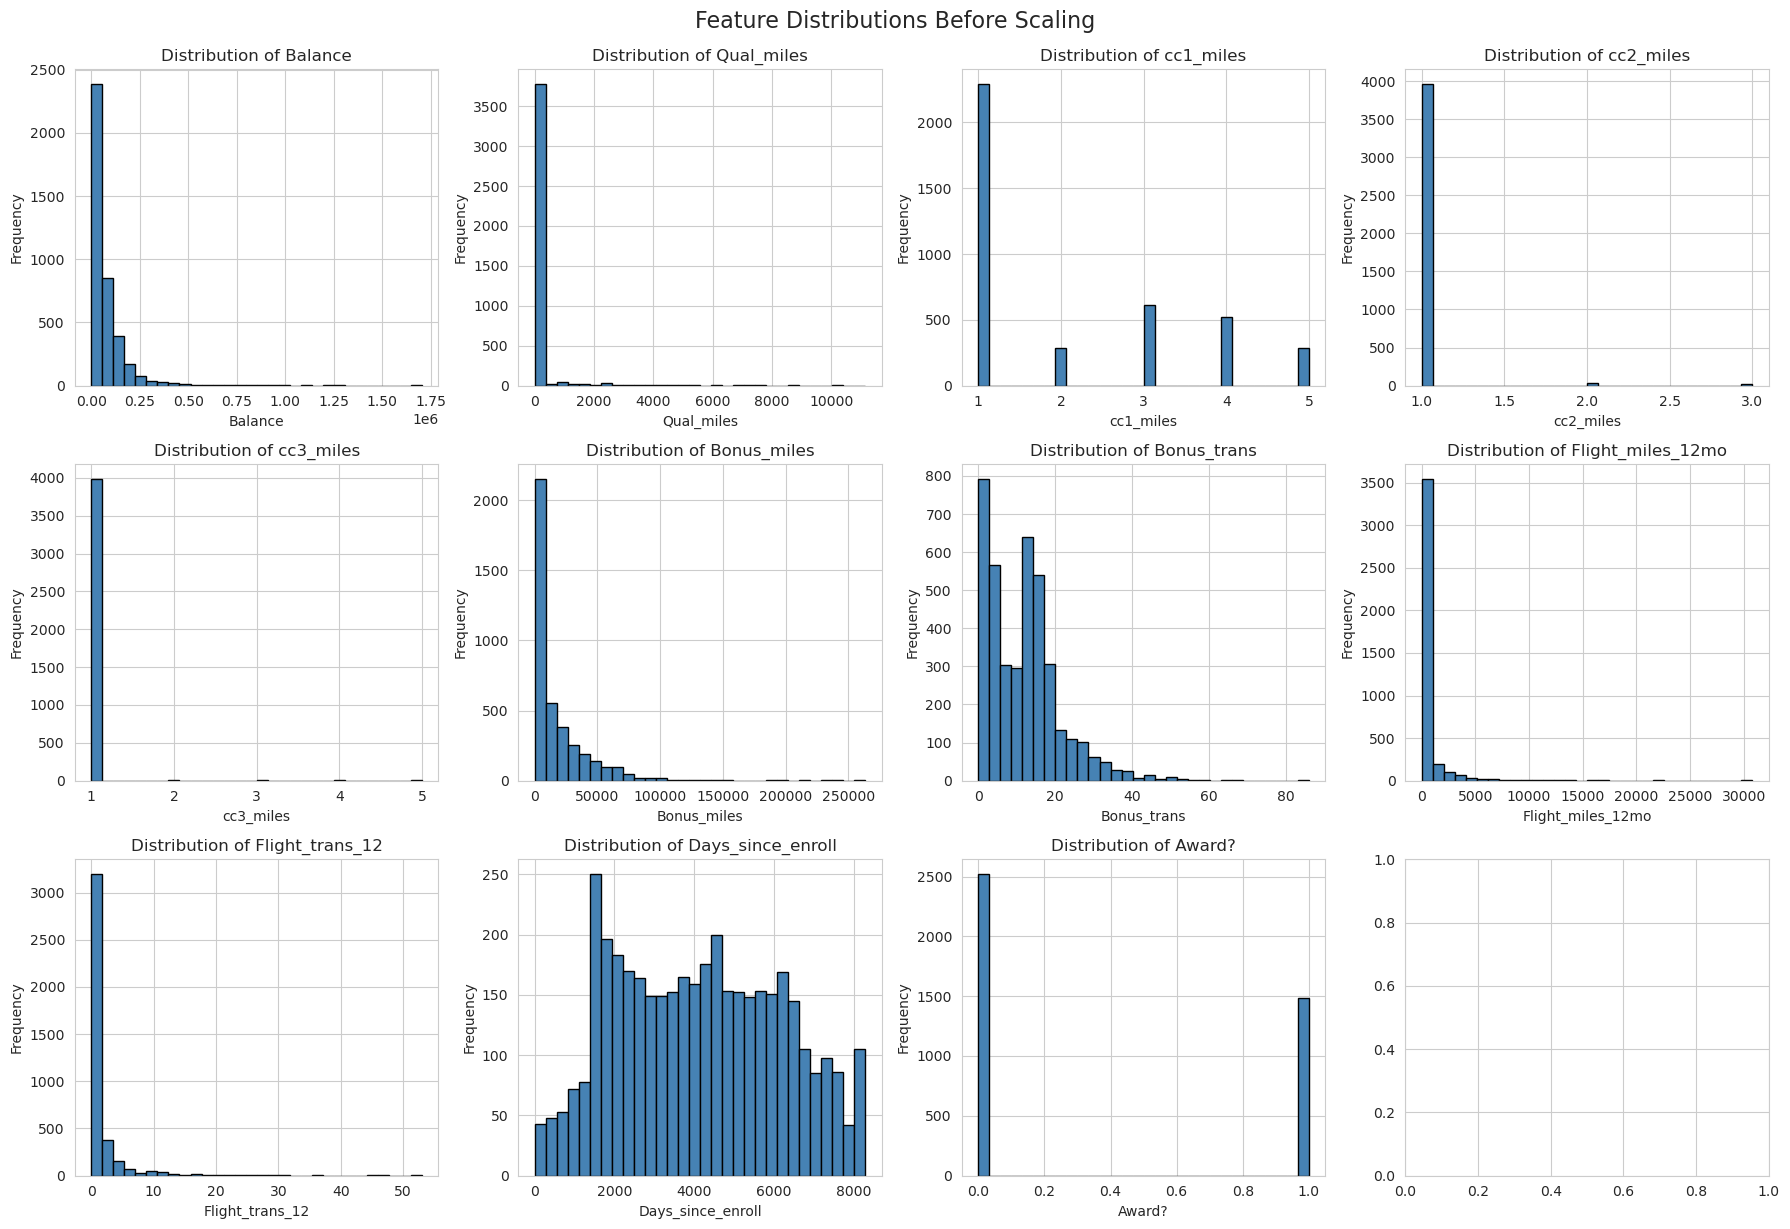

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    axes[i].hist(df_clean[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Feature Distributions Before Scaling', y=1.02, fontsize=16)
plt.show()

In [8]:
skewness = df_clean.skew().sort_values(ascending=False)
print("Skewness of each feature:")
print(skewness)

Skewness of each feature:
cc3_miles            17.195532
cc2_miles            11.210459
Qual_miles            7.512395
Flight_miles_12mo     7.451666
Flight_trans_12       5.490461
Balance               5.004187
Bonus_miles           2.842093
Bonus_trans           1.157362
cc1_miles             0.857569
Award?                0.537200
Days_since_enroll     0.120174
dtype: float64


In [9]:
skewed_cols = ['Balance', 'Qual_miles', 'Bonus_miles', 'Bonus_trans',
               'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']

df_log = df_clean.copy()
for col in skewed_cols:
    df_log[col] = np.log1p(df_log[col])
print("Skewness after log transformation:")
print(df_log[skewed_cols].skew())

Skewness after log transformation:
Balance             -0.831013
Qual_miles           3.914590
Bonus_miles         -1.485210
Bonus_trans         -0.785392
Flight_miles_12mo    0.916755
Flight_trans_12      1.829923
Days_since_enroll   -2.062545
dtype: float64


In [10]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_log), columns=df_log.columns)

print("Mean after scaling (should be ~0):")
print(df_scaled.mean().round(4))

print("\nStd after scaling (should be ~1):")
print(df_scaled.std().round(4))

Mean after scaling (should be ~0):
Balance             -0.0
Qual_miles           0.0
cc1_miles            0.0
cc2_miles            0.0
cc3_miles            0.0
Bonus_miles         -0.0
Bonus_trans         -0.0
Flight_miles_12mo    0.0
Flight_trans_12     -0.0
Days_since_enroll   -0.0
Award?               0.0
dtype: float64

Std after scaling (should be ~1):
Balance              1.0001
Qual_miles           1.0001
cc1_miles            1.0001
cc2_miles            1.0001
cc3_miles            1.0001
Bonus_miles          1.0001
Bonus_trans          1.0001
Flight_miles_12mo    1.0001
Flight_trans_12      1.0001
Days_since_enroll    1.0001
Award?               1.0001
dtype: float64


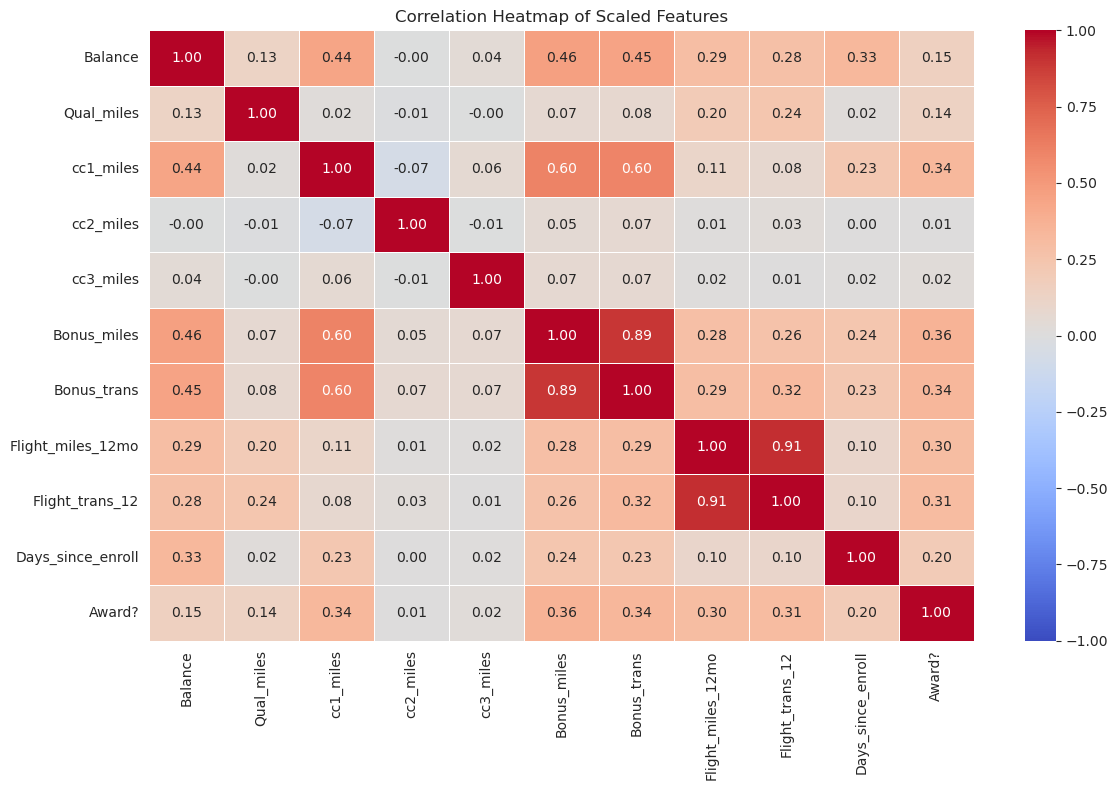

In [11]:
plt.figure(figsize=(12, 8))
corr_matrix = df_scaled.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Scaled Features')
plt.tight_layout()
plt.show()

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


K=2 | WCSS=34759.98 | Silhouette=0.2259
K=3 | WCSS=29336.18 | Silhouette=0.2410
K=4 | WCSS=25665.73 | Silhouette=0.2475
K=5 | WCSS=22582.56 | Silhouette=0.2692
K=6 | WCSS=19761.57 | Silhouette=0.2315
K=7 | WCSS=16787.70 | Silhouette=0.2610
K=8 | WCSS=15233.97 | Silhouette=0.2699
K=9 | WCSS=13987.67 | Silhouette=0.2715
K=10 | WCSS=12872.55 | Silhouette=0.2820


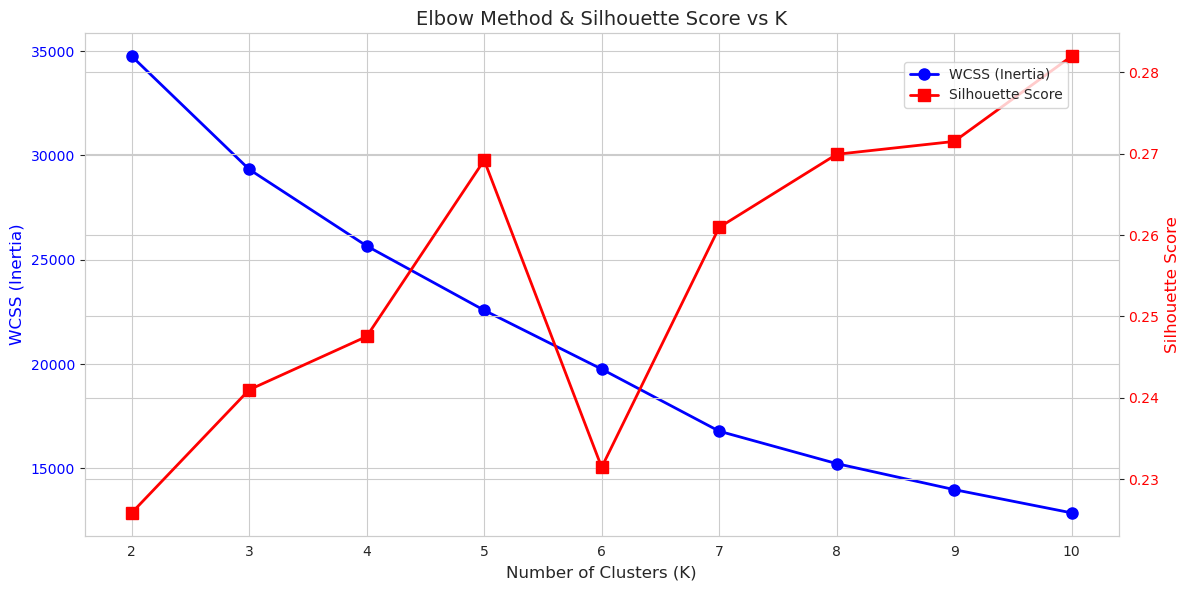

In [12]:
wcss = []  
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    sil_score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"K={k} | WCSS={kmeans.inertia_:.2f} | Silhouette={sil_score:.4f}")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8, label='WCSS (Inertia)')
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Elbow Method & Silhouette Score vs K', fontsize=14)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

In [13]:
optimal_k = 5  

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_final.fit(df_scaled)
df['KMeans_Cluster'] = kmeans_final.labels_

print(f"Cluster sizes for K={optimal_k}:")
print(df['KMeans_Cluster'].value_counts().sort_index())

print(f"\nSilhouette Score: {silhouette_score(df_scaled, kmeans_final.labels_):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(df_scaled, kmeans_final.labels_):.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(df_scaled, kmeans_final.labels_):.4f}")

Cluster sizes for K=5:
KMeans_Cluster
0    1048
1    1716
2     214
3    1006
4      15
Name: count, dtype: int64

Silhouette Score: 0.2692
Davies-Bouldin Index: 1.1796
Calinski-Harabasz Index: 946.4976


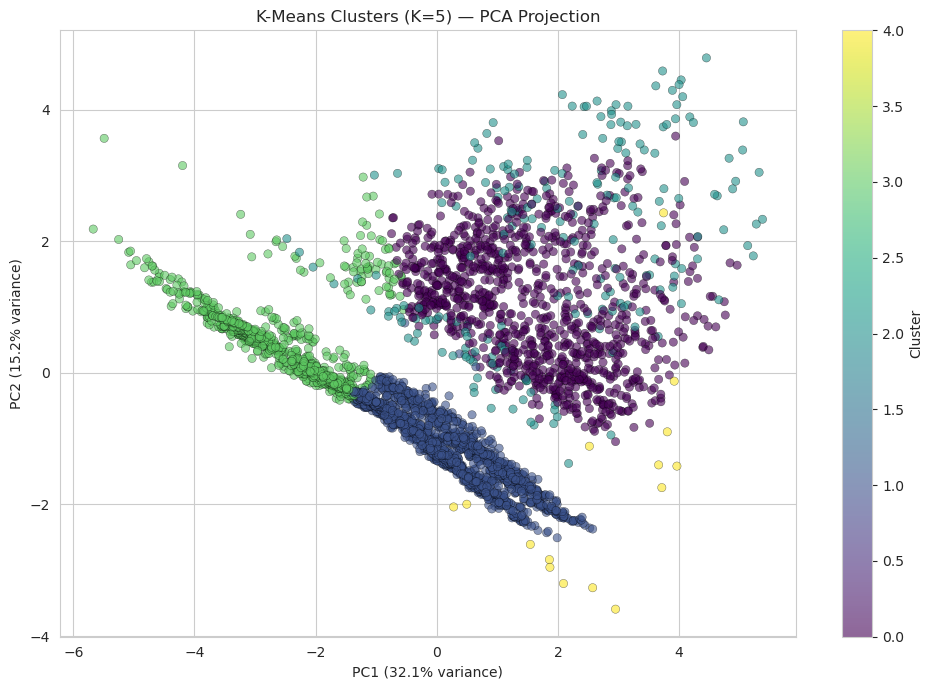

Total variance explained by 2 PCs: 47.3%


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
                      c=df['KMeans_Cluster'], cmap='viridis',
                      alpha=0.6, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'K-Means Clusters (K={optimal_k}) — PCA Projection')
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%")

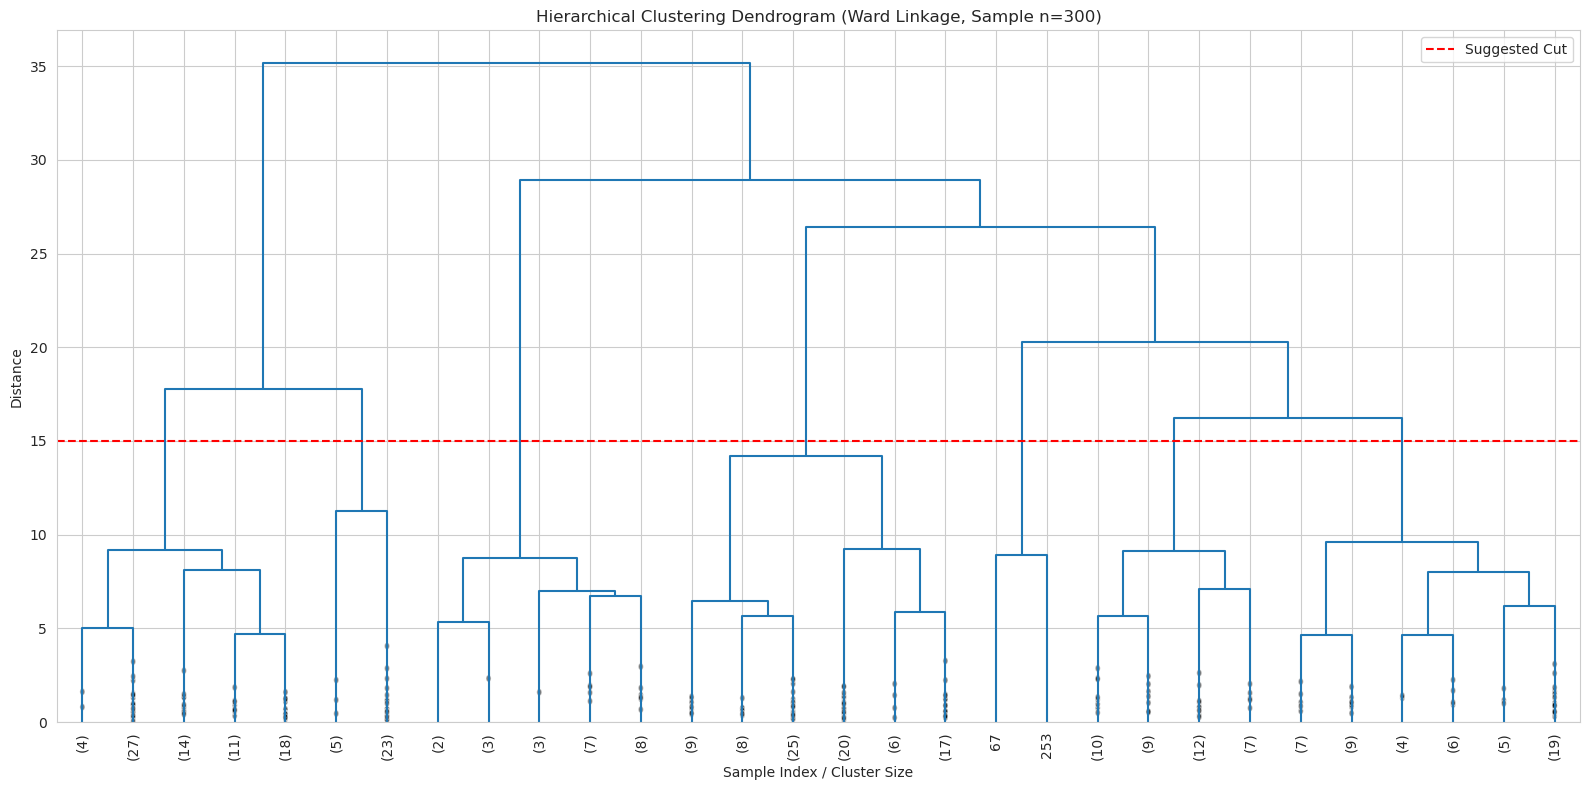

In [16]:
np.random.seed(42)
sample_idx = np.random.choice(df_scaled.index, size=300, replace=False)
df_sample = df_scaled.loc[sample_idx]

# Compute linkage matrix
linkage_matrix = linkage(df_sample, method='ward') 

plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10,
           show_contracted=True, color_threshold=0)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, Sample n=300)')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance')
plt.axhline(y=15, color='red', linestyle='--', label='Suggested Cut')  
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
hier_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hier_model.fit_predict(df_scaled)

df['Hier_Cluster'] = hier_labels

print(f"Hierarchical Cluster sizes (K={optimal_k}):")
print(df['Hier_Cluster'].value_counts().sort_index())

print(f"\nSilhouette Score: {silhouette_score(df_scaled, hier_labels):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(df_scaled, hier_labels):.4f}")

Hierarchical Cluster sizes (K=5):
Hier_Cluster
0    1319
1    2155
2     464
3      43
4      18
Name: count, dtype: int64

Silhouette Score: 0.2634
Davies-Bouldin Index: 1.1239


Cluster Agreement (Crosstab):
Hierarchical     0     1    2   3   4
K-Means                              
0             1031     2    0  15   0
1                3  1683    0  27   3
2              213     0    0   1   0
3               72   470  464   0   0
4                0     0    0   0  15


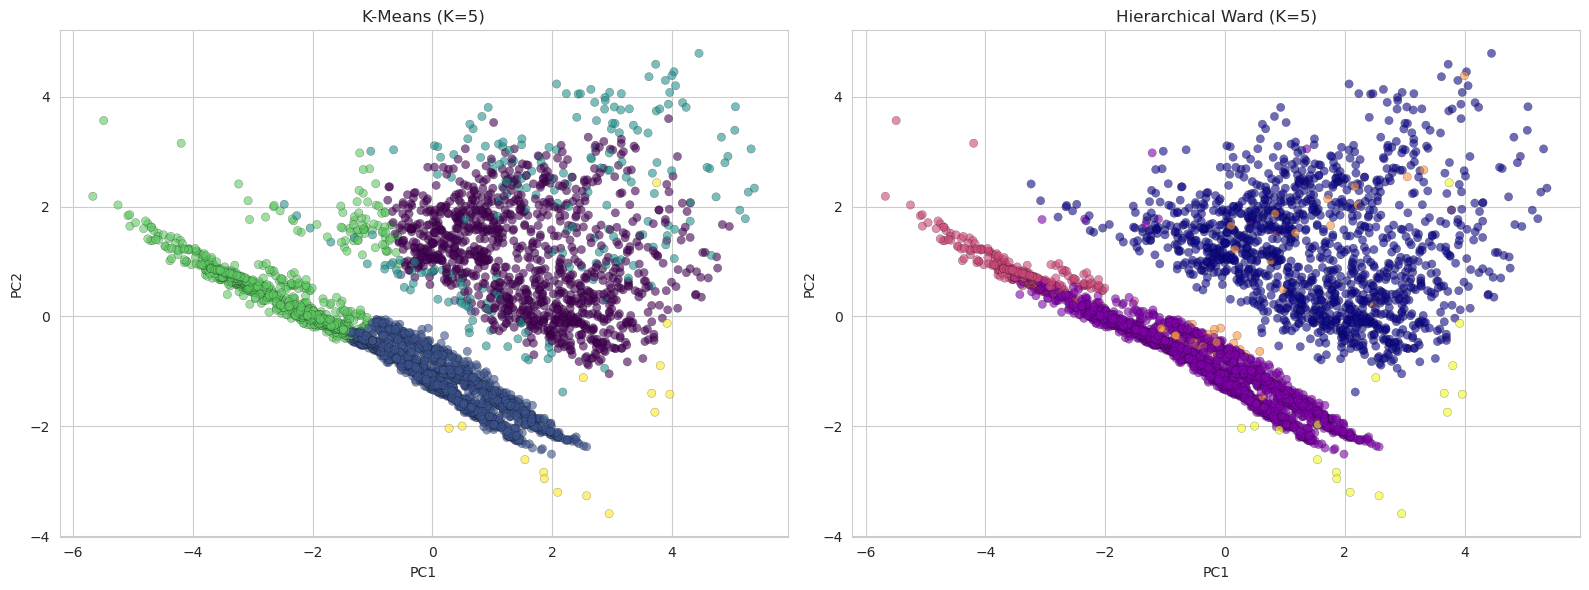

In [18]:
comparison = pd.crosstab(df['KMeans_Cluster'], df['Hier_Cluster'],
                         rownames=['K-Means'], colnames=['Hierarchical'])
print("Cluster Agreement (Crosstab):")
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(pca_result[:, 0], pca_result[:, 1],
                c=df['KMeans_Cluster'], cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.2)
axes[0].set_title(f'K-Means (K={optimal_k})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(pca_result[:, 0], pca_result[:, 1],
                c=df['Hier_Cluster'], cmap='plasma', alpha=0.6, edgecolors='k', linewidth=0.2)
axes[1].set_title(f'Hierarchical Ward (K={optimal_k})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [19]:
profile_cols = ['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
                'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo',
                'Flight_trans_12', 'Days_since_enroll', 'Award?']

cluster_profile = df.groupby('KMeans_Cluster')[profile_cols].mean().round(2)
print("K-Means Cluster Profiles (Means):")
print(cluster_profile.T)

print("\nCluster Sizes:")
print(df['KMeans_Cluster'].value_counts().sort_index())

K-Means Cluster Profiles (Means):
KMeans_Cluster             0         1          2         3          4
Balance            108948.58  73704.73  139046.61  21719.08  138061.40
Qual_miles              0.00      0.00    2556.71     27.83      78.80
cc1_miles               2.36      2.46       2.25      1.00       3.47
cc2_miles               1.02      1.02       1.01      1.00       1.00
cc3_miles               1.00      1.00       1.00      1.00       4.07
Bonus_miles         24996.10  20236.73   25291.85    813.84   93927.87
Bonus_trans            15.84     14.10      16.34      1.67      28.07
Flight_miles_12mo    1358.07      0.09    1805.76     22.18     506.67
Flight_trans_12         4.02      0.00       5.44      0.09       1.60
Days_since_enroll    4473.27   4355.68    4418.90   3273.30    4613.87
Award?                  0.57      0.37       0.68      0.08       0.53

Cluster Sizes:
KMeans_Cluster
0    1048
1    1716
2     214
3    1006
4      15
Name: count, dtype: int64


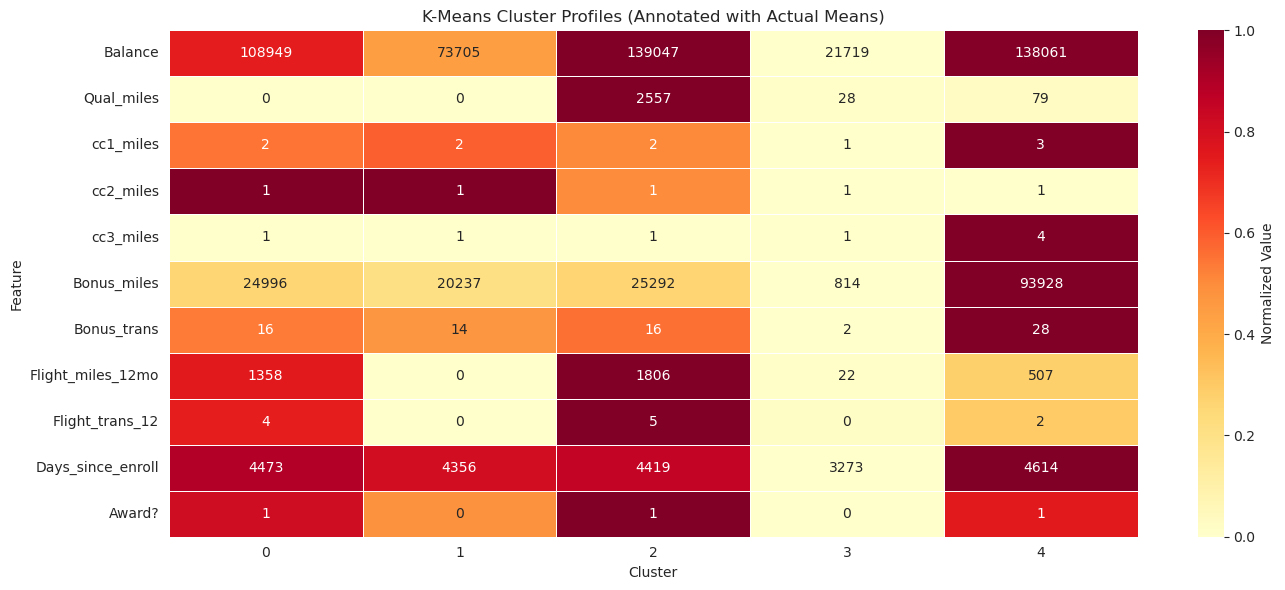

In [20]:
from sklearn.preprocessing import MinMaxScaler
profile_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(14, 6))
sns.heatmap(profile_scaled.T, annot=cluster_profile.T, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Normalized Value'})
plt.title('K-Means Cluster Profiles (Annotated with Actual Means)')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 18: ANOVA TEST FOR CLUSTER SEPARATION
# ============================================================
from scipy.stats import f_oneway

print("ANOVA F-test p-values (testing if clusters differ significantly):")
for col in profile_cols:
    groups = [df[df['KMeans_Cluster'] == k][col] for k in range(optimal_k)]
    f_stat, p_val = f_oneway(*groups)
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"{col:25s} | F={f_stat:8.2f} | p={p_val:.2e} {significance}")